In [ ]:
import sys
import pandas as pd
import numpy as np
import polars as pl
import plotly.express as px
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, data_utils, analysis, plots

TRAIN_PATH  = config.TRAIN_PATH
RAW_PATH    = config.RAW_PATH
OUTPUT_PATH = config.DATA_DIR / "common_zero_var_cols.csv"
COL_DROP_FILE = config.DATA_DIR / "columns_to_drop.csv"
FIGURES_DIR = config.FIGURES_DIR

# 0 variance columns

In [2]:
def main():

    print("Reading train.parquet...")
    df = pl.read_parquet(TRAIN_PATH)
    print(f"Shape: {df.shape}")

    print("Computing zero-variance metrics...")
    zero_var = (
        df.group_by("metric")
        .agg(pl.col("value").n_unique().alias("n_unique"))
        .filter(pl.col("n_unique") == 1)
        .select("metric")
        .sort("metric")
    )

    print(f"Zero-variance metrics found: {len(zero_var)}")

    zero_var.write_csv(OUTPUT_PATH)
    print(f"Saved to {OUTPUT_PATH}")

main()

Reading train.parquet...
Shape: (203205223, 3)
Computing zero-variance metrics...
Zero-variance metrics found: 2810
Saved to C:\Users\Shruti\OneDrive\Desktop\UBC\DSCI591\DevBranch\AdaptiveSats\data\common_zero_var_cols.csv


In [3]:
# load zero-var column names from CSV
constant_cols = pd.read_csv(OUTPUT_PATH)['metric'].tolist()

# read and filter to only zero-var metrics (cheaper to pivot a subset)
df_check_variance = pl.read_parquet(TRAIN_PATH)
df_check_variance_filtered = df_check_variance.filter(pl.col('metric').is_in(constant_cols))

# pivot to wide formats
df_check_variance_filtered_wide = (
    df_check_variance_filtered
    .pivot(index='day_utc', on='metric', values='value')
    .sort('day_utc')
)

# check which columns are strictly zero (min==0 AND max==0)
df_var_pd = df_check_variance_filtered_wide.drop('day_utc').to_pandas()
is_strictly_zero = (df_var_pd.max() == 0) & (df_var_pd.min() == 0)


strictly_zero_cols = df_var_pd.columns[is_strictly_zero].tolist()

# columns that only have value of 0
df_zero_cols = df_var_pd.loc[:, is_strictly_zero]


print(f"Zero-variance columns (from CSV): {len(constant_cols)}")
print(f"Strictly columns with only value is 0: {len(strictly_zero_cols)}")

Zero-variance columns (from CSV): 2810
Strictly columns with only value is 0: 2626


In [4]:
df_var_pd.describe()

,10y_dca_days_in_loss,10y_lump_sum_days_in_loss,4y_dca_days_in_loss,4y_lump_sum_days_in_loss,5y_dca_days_in_loss,6y_dca_days_in_loss,6y_lump_sum_days_in_loss,8y_dca_days_in_loss,8y_lump_sum_days_in_loss,addrs_above_100btc_under_1k_btc_min_cost_basis,...,year_2026_supply_in_profit_usd,year_2026_supply_usd,year_2026_total_realized_pnl,year_2026_total_unrealized_pnl,year_2026_unrealized_loss,year_2026_unrealized_profit,year_2026_utxo_count,year_2026_utxo_count_30d_change,year_2026_value_created,year_2026_value_destroyed
count,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5464.0,...,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0,5471.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Dendogram and VIF- Full cost basis

In [5]:
train = pl.read_parquet(TRAIN_PATH)

In [6]:
full_cost_basis = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("cost_basis_"))
    .collect()
)
len(full_cost_basis)
full_cost_basis_df = full_cost_basis.to_pandas()

In [7]:
full_cost_basis_df = full_cost_basis_df.pivot(columns='metric',index='day_utc', values='value')

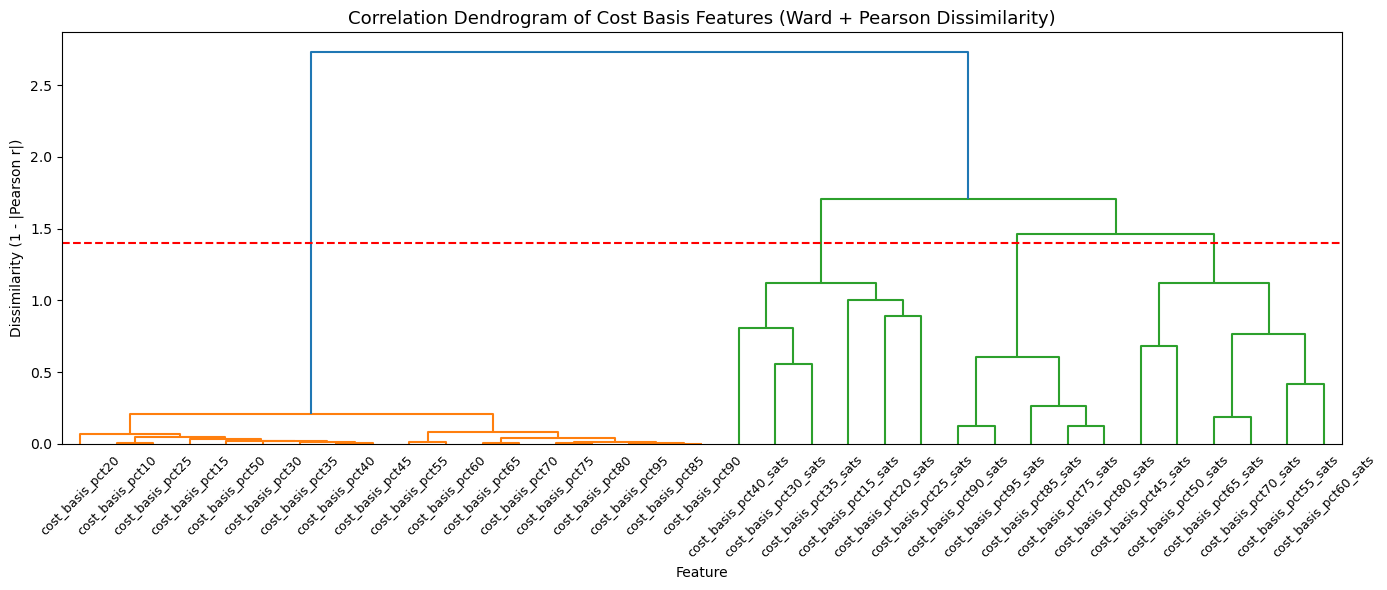

In [ ]:
wide_cost    = data_utils.load_metric_wide(TRAIN_PATH, pl.col("metric").str.starts_with("cost_basis_"))
corr, Z      = analysis.compute_correlation_linkage(wide_cost)
plots.plot_dendrogram(Z, corr.columns.tolist(), title="Correlation Dendrogram of Cost Basis Features (Ward + Pearson Dissimilarity)", threshold=1.4)

In [10]:
clusters_cost = fcluster(Z, t=1.4, criterion="distance")

cluster_map_cost = dict(zip(wide_cost.columns, clusters_cost))

cluster_df_cost = pd.DataFrame({
    "feature": wide_cost.columns,
    "cluster": clusters_cost
})
cluster_df_cost.head()

,feature,cluster
0,cost_basis_pct10,1
1,cost_basis_pct15,1
2,cost_basis_pct15_sats,2
3,cost_basis_pct20,1
4,cost_basis_pct20_sats,2


In [11]:
cluster_df_cost.groupby("cluster").size()

cluster
1    18
2     6
3     5
4     6
dtype: int64

In [12]:
n = cluster_df_cost["cluster"].nunique()
clusters = {}
for i in range(1, n+1):
    clusters[i] = cluster_df_cost[cluster_df_cost["cluster"] == i]["feature"].tolist()

In [ ]:
high_vif = analysis.compute_vif_clusters(train, clusters)


Cluster 1:
cost_basis_pct90    3340.302751
cost_basis_pct85    3136.013152
cost_basis_pct95    2304.347034
cost_basis_pct75     858.957195
cost_basis_pct80     794.469413
cost_basis_pct70     549.128335
cost_basis_pct35     470.501486
cost_basis_pct65     421.481814
cost_basis_pct60     373.742085
cost_basis_pct40     372.222952
cost_basis_pct25     354.360684
cost_basis_pct10     338.903969
cost_basis_pct45     317.428026
cost_basis_pct50     282.638424
cost_basis_pct55     259.721912
cost_basis_pct30     241.250626
cost_basis_pct20     209.689172
cost_basis_pct15     116.356658

  High VIF cols (>10.0): ['cost_basis_pct10', 'cost_basis_pct15', 'cost_basis_pct20', 'cost_basis_pct25', 'cost_basis_pct30', 'cost_basis_pct35', 'cost_basis_pct40', 'cost_basis_pct45', 'cost_basis_pct50', 'cost_basis_pct55', 'cost_basis_pct60', 'cost_basis_pct65', 'cost_basis_pct70', 'cost_basis_pct75', 'cost_basis_pct80', 'cost_basis_pct85', 'cost_basis_pct90', 'cost_basis_pct95']

Cluster 2:
cost_basis_pc

In [14]:
all_high_vif_cost_basis = [col for cols in high_vif.values() for col in cols]

# Dendogram and VIF - Address Columns

In [15]:
full_address = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.starts_with("addrs"))
    .collect()
)
len(full_address)
full_address_pd = full_address.to_pandas()

In [16]:
full_address_df = full_address_pd.pivot(columns='metric',index='day_utc', values='value')

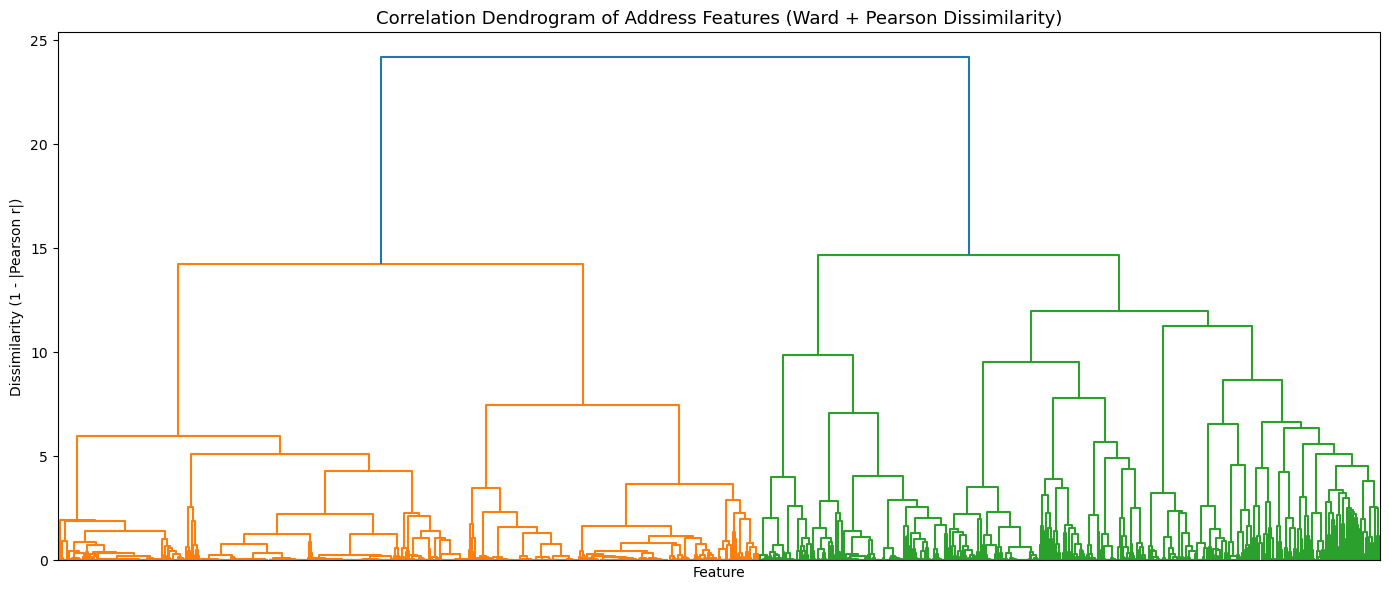

In [ ]:
wide_addrs    = data_utils.load_metric_wide(TRAIN_PATH, pl.col("metric").str.starts_with("addrs"))
corr, Z      = analysis.compute_correlation_linkage(wide_addrs)
plots.plot_dendrogram(Z, corr.columns.tolist(), title="Correlation Dendrogram of Address Features (Ward + Pearson Dissimilarity)", no_labels=True)

Due to the large number of metrics in this family, I suggest using a threshold of 5. This will give us 20 clusters each with a relatively smaller subset of metrics.

In [19]:
clusters_addrs = fcluster(Z, t=5, criterion="distance")

cluster_map_addrs = dict(zip(wide_addrs.columns, clusters_addrs))


cluster_df_addrs = pd.DataFrame({
    "feature": wide_addrs.columns,
    "cluster": clusters_addrs
})
cluster_df_addrs.head()

,feature,cluster
0,addrs_above_100btc_under_1k_btc__30d_change,20
1,addrs_above_100btc_under_1k_btc__30d_change_btc,20
2,addrs_above_100btc_under_1k_btc__30d_change_usd,6
3,addrs_above_100btc_under_1k_btc_addr_count,9
4,addrs_above_100btc_under_1k_btc_addr_count_30d...,20


In [20]:
cluster_df_addrs["cluster"].value_counts().sort_index()

cluster
1      489
2       52
3     1033
4      416
5      694
6      200
7      121
8      405
9      346
10     181
11      53
12     181
13     183
14     123
15      91
16      94
17      78
18      52
19      54
20     211
Name: count, dtype: int64

In [ ]:
n = cluster_df_addrs["cluster"].nunique()
clusters_addrs_dict = {}
for i in range(1, n+1):
    clusters_addrs_dict[i] = cluster_df_addrs[cluster_df_addrs["cluster"] == i]["feature"].tolist()

high_vif_addrs = analysis.compute_vif_clusters(train, clusters_addrs_dict)


Cluster 1:


c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


addrs_under_10k_sats_supply                                                        5.629500e+13
addrs_under_1m_sats_supply_in_profit                                               3.832851e+13
addrs_under_1k_sats_supply_btc                                                     2.982516e+13
addrs_above_100sats_under_1k_sats_supply_btc                                       2.251800e+13
addrs_above_1m_sats_under_10m_sats_supply_halved                                   1.387858e+13
addrs_above_100sats_under_1k_sats_supply_halved                                    8.980258e+12
addrs_above_100k_sats_under_1m_sats_utxo_count                                     6.886238e+12
addrs_under_1btc_sent_in_profit_btc_cumulative                                     3.458986e+12
addrs_under_10k_btc_sent_in_loss_cumulative                                        3.179386e+12
addrs_under_100k_sats_sent_in_profit_btc_cumulative                                3.144972e+12
addrs_above_1m_sats_under_10m_sats_utxo_

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


addrs_above_1k_sats_under_10k_sats_capitulation_flow                             inf
addrs_above_1k_sats_under_10k_sats_loss_value_created                            inf
addrs_above_1k_sats_under_10k_sats_neg_realized_loss                             inf
addrs_above_1k_sats_under_10k_sats_loss_value_destroyed                          inf
addrs_above_1k_sats_under_10k_sats_sent_in_loss_usd                              inf
addrs_above_1k_sats_under_10k_sats_sent_in_loss_btc                              inf
addrs_above_1k_sats_under_10k_sats_profit_flow                                   inf
addrs_above_1k_sats_under_10k_sats_profit_value_created                          inf
addrs_above_1k_sats_under_10k_sats_realized_loss                                 inf
addrs_above_1k_sats_under_10k_sats_profit_value_destroyed                        inf
addrs_above_1k_sats_under_10k_sats_sent                                          inf
addrs_above_1k_sats_under_10k_sats_realized_value                

...

addrs_above_10sats_under_100sats_coinblocks_destroyed                   inf
addrs_above_10sats_under_100sats_coindays_destroyed                     inf
addrs_above_10sats_under_100sats_sent                                   inf
addrs_above_10sats_under_100sats_sent_14d_ema_btc                       inf
addrs_above_1sat_under_10sats_sent_in_loss                              inf
addrs_above_10sats_under_100sats_sent_btc                               inf
addrs_above_10sats_under_100sats_sent_in_profit                         inf
addrs_above_10sats_under_100sats_sent_in_profit_14d_ema_btc             inf
addrs_above_1sat_under_10sats_coinblocks_destroyed                      inf
addrs_above_10sats_under_100sats_sent_in_profit_btc                     inf
addrs_above_1sat_under_10sats_coindays_destroyed                        inf
addrs_above_1sat_under_10sats_sent                                      inf
addrs_above_1sat_under_10sats_sent_in_loss_14d_ema_btc                  inf
addrs_above_

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


addrs_above_100k_sats_under_1m_sats__30d_change                        inf
addrs_above_100k_sats_under_1m_sats__30d_change_btc                    inf
addrs_above_100k_sats_under_1m_sats_addr_count_30d_change              inf
addrs_above_100k_sats_under_1m_sats_utxo_count_30d_change              inf
addrs_above_10k_sats_under_100k_sats__30d_change_btc                   inf
addrs_above_10k_sats_under_100k_sats_addr_count_30d_change             inf
addrs_over_100k_sats_addr_count_30d_change                             inf
addrs_above_10k_sats_under_100k_sats_utxo_count_30d_change             inf
addrs_above_10m_sats_under_1btc_utxo_count_30d_change                  inf
addrs_above_1btc_under_10btc_utxo_count_30d_change                     inf
addrs_above_1m_sats_under_10m_sats__30d_change                         inf
addrs_above_1m_sats_under_10m_sats__30d_change_btc                     inf
addrs_above_1m_sats_under_10m_sats_addr_count_30d_change               inf
addrs_above_1m_sats_under

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


addrs_above_100k_btc_realized_profit                                                              4.106710e+08
addrs_above_100k_btc_realized_profit_7d_ema                                                       2.736433e+08
addrs_over_1k_btc_utxo_count_30d_change                                                           1.456399e+08
addrs_above_100k_btc_realized_loss                                                                1.328226e+08
addrs_above_100k_btc_net_realized_pnl_7d_ema                                                      1.002590e+08
addrs_above_100k_btc_neg_realized_loss                                                            9.880787e+07
addrs_above_100btc_under_1k_btc_utxo_count_30d_change                                             9.056372e+07
addrs_above_100k_btc_total_realized_pnl                                                           8.480790e+07
addrs_above_10btc_under_100btc_utxo_count_30d_change                                              7.765115e+07
a

In [22]:
all_high_vif_addrs = [col for cols in high_vif_addrs.values() for col in cols]

# Dendogram and VIF - DCA Strategy

In [23]:
full_dca_family = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("dca_"))
    .collect()
)

full_dca_df = full_dca_family.to_pandas()

In [24]:
full_dca_df = full_dca_df.pivot(columns='metric',index='day_utc', values='value')
len(full_dca_df.columns)

238

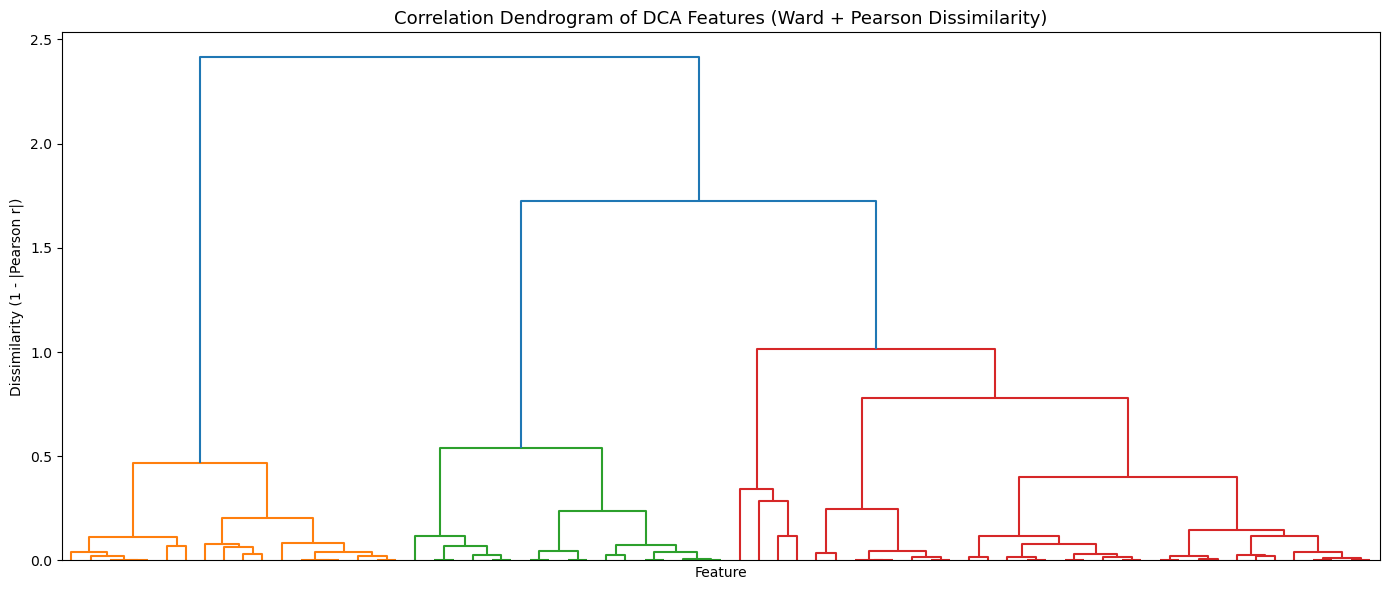

In [ ]:
wide_dca    = data_utils.load_metric_wide(TRAIN_PATH, pl.col("metric").str.starts_with("dca_"))
corr, Z      = analysis.compute_correlation_linkage(wide_dca)
plots.plot_dendrogram(Z, corr.columns.tolist(), title="Correlation Dendrogram of DCA Features (Ward + Pearson Dissimilarity)", no_labels=True)

In [26]:
clusters_dca = fcluster(Z, t=1.5, criterion="distance")

cluster_map_dca = dict(zip(wide_dca.columns, clusters_dca))


cluster_df_dca = pd.DataFrame({
    "feature": wide_dca.columns,
    "cluster": clusters_dca
})
cluster_df_dca.head()

,feature,cluster
0,dca_class_2015_average_price,3
1,dca_class_2015_average_price_sats,3
2,dca_class_2015_days_in_loss,2
3,dca_class_2015_days_in_profit,3
4,dca_class_2015_max_return,2


In [27]:
cluster_df_dca["cluster"].value_counts().sort_index()

cluster
1    18
2    17
3    34
Name: count, dtype: int64

In [ ]:
n = cluster_df_dca["cluster"].nunique()
clusters_dca_dict = {}
for i in range(1, n+1):
    clusters_dca_dict[i] = cluster_df_dca[cluster_df_dca["cluster"] == i]["feature"].tolist()

high_vif_dca = analysis.compute_vif_clusters(train, clusters_dca_dict)


Cluster 1:


c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


dca_class_2021_stack                      inf
dca_class_2021_stack_btc                  inf
dca_class_2023_stack                      inf
dca_class_2022_stack_btc                  inf
dca_class_2022_stack                      inf
dca_class_2023_stack_btc                  inf
dca_class_2023_days_in_profit    1.728249e+04
dca_class_2022_days_in_loss      9.010106e+03
dca_class_2022_stack_usd         2.265982e+03
dca_class_2021_days_in_loss      2.254842e+03
dca_class_2023_stack_usd         1.685586e+03
dca_class_2022_days_in_profit    1.404727e+03
dca_class_2021_stack_usd         4.332884e+02
dca_class_2022_max_return        1.990167e+02
dca_class_2022_min_return        1.870602e+02
dca_class_2023_max_return        1.222806e+02
dca_class_2023_days_in_loss      3.776952e+01
dca_class_2023_min_return        2.449553e+01

  High VIF cols (>10.0): ['dca_class_2021_days_in_loss', 'dca_class_2021_stack', 'dca_class_2021_stack_btc', 'dca_class_2021_stack_usd', 'dca_class_2022_days_in_loss', 'dc

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


dca_class_2015_stack_btc                inf
dca_class_2017_stack_btc                inf
dca_class_2015_stack                    inf
dca_class_2017_stack                    inf
dca_class_2016_stack_btc                inf
dca_class_2016_stack           3.002400e+15
dca_class_2016_max_return      5.188941e+04
dca_class_2017_max_return      2.944438e+04
dca_class_2015_max_return      3.608662e+03
dca_class_2015_days_in_loss    1.289121e+03
dca_class_2017_days_in_loss    5.072263e+02
dca_class_2017_min_return      3.299382e+02
dca_class_2016_days_in_loss    2.926760e+02
dca_class_2016_min_return      2.328831e+02
dca_class_2018_min_return      8.593770e+01
dca_class_2018_days_in_loss    8.224782e+01
dca_class_2015_min_return      2.224127e+01

  High VIF cols (>10.0): ['dca_class_2015_days_in_loss', 'dca_class_2015_max_return', 'dca_class_2015_min_return', 'dca_class_2015_stack', 'dca_class_2015_stack_btc', 'dca_class_2016_days_in_loss', 'dca_class_2016_max_return', 'dca_class_2016_min_retu

c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


dca_class_2018_stack_btc                      inf
dca_class_2018_stack                          inf
dca_class_2020_stack_btc                      inf
dca_class_2020_stack                          inf
dca_class_2019_stack_btc                      inf
dca_class_2019_stack                          inf
dca_class_2016_stack_usd             2.364170e+07
dca_class_2015_average_price         1.444839e+07
dca_class_2015_stack_usd             1.354641e+07
dca_class_2015_days_in_profit        1.223736e+07
dca_class_2016_average_price         4.925350e+06
dca_class_2016_days_in_profit        3.988142e+06
dca_class_2017_stack_usd             3.709917e+06
dca_class_2019_days_in_profit        4.523903e+05
dca_class_2015_returns               3.463150e+05
dca_class_2018_stack_usd             2.457090e+05
dca_class_2016_returns               2.142361e+05
dca_class_2019_stack_usd             1.312253e+05
dca_class_2017_days_in_profit        1.234206e+05
dca_class_2018_days_in_profit        1.101496e+05


In [29]:
all_high_vif_dca = [col for cols in high_vif_dca.values() for col in cols]
len(all_high_vif_dca)

69

# Mining Pool Dendogram and VIF 

In [30]:
full_mining_family = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").str.contains("pool"))
    .collect()
)
len(full_mining_family)
full_mining_df = full_mining_family.to_pandas()

In [31]:
full_mining_df = full_mining_df.pivot(columns='metric',index='day_utc', values='value')
len(full_mining_df.columns)

1612

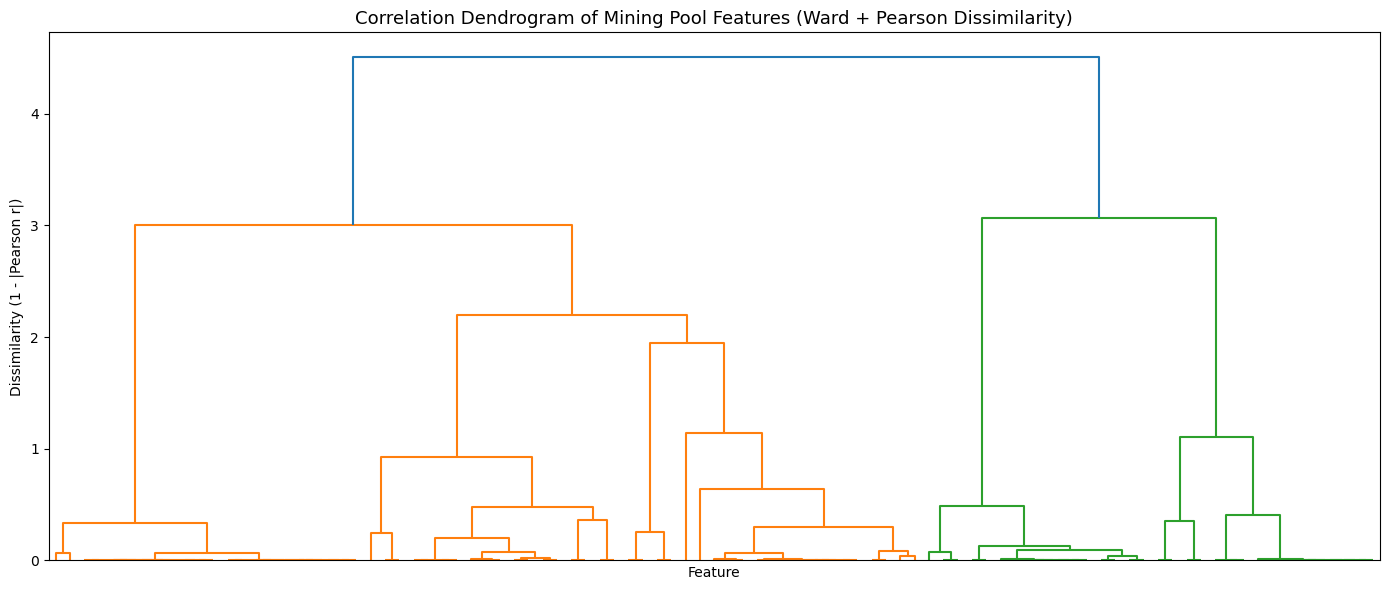

In [ ]:
wide_mining    = data_utils.load_metric_wide(TRAIN_PATH, pl.col("metric").str.starts_with("pool"))
corr, Z      = analysis.compute_correlation_linkage(wide_mining)
plots.plot_dendrogram(Z, corr.columns.tolist(), title="Correlation Dendrogram of Mining Pool Features (Ward + Pearson Dissimilarity)", no_labels=True)

In [34]:
clusters_mining_pool = fcluster(Z, t=5, criterion="distance")

cluster_map_mining_pool = dict(zip(wide_mining.columns, clusters_mining_pool))


cluster_df_mining_pool = pd.DataFrame({
    "feature": wide_mining.columns,
    "cluster": clusters_mining_pool
})
cluster_df_mining_pool.head()

,feature,cluster
0,pool175btc_1m_blocks_mined,1
1,pool175btc_1m_dominance,1
2,pool175btc_1w_blocks_mined,1
3,pool175btc_1w_dominance,1
4,pool175btc_1y_blocks_mined,1


In [35]:
cluster_df_mining_pool["cluster"].value_counts().sort_index()

cluster
1    93
Name: count, dtype: int64

In [ ]:
n = cluster_df_mining_pool["cluster"].nunique()
clusters_mining_pool_dict = {}
for i in range(1, n+1):
    clusters_mining_pool_dict[i] = cluster_df_mining_pool[cluster_df_mining_pool["cluster"] == i]["feature"].tolist()

high_vif_mining_pool = analysis.compute_vif_clusters(train, clusters_mining_pool_dict)


Cluster 1:


c:\Users\Shruti\miniforge3\envs\adaptivesats\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


poolin_subsidy_cumulative             6.479999e+13
poolin_fee_cumulative                 6.716778e+12
poolin_coinbase_usd_cumulative        5.114821e+12
poolin_coinbase_cumulative            5.026339e+12
poolin_coinbase_btc_cumulative        4.160369e+12
poolin_coinbase_btc                   4.051822e+12
poolin_fee_usd                        2.158447e+12
poolin_subsidy                        1.713373e+12
pool50btc_coinbase_usd                1.615351e+12
poolin_fee_btc                        1.601565e+12
pool50btc_fee_cumulative              1.197766e+12
poolin_fee_btc_cumulative             1.037576e+12
pool175btc_coinbase_usd_cumulative    9.504273e+11
pool50btc_blocks_mined                6.689342e+11
poolin_subsidy_usd_cumulative         6.147000e+11
pool50btc_coinbase_btc                5.784971e+11
poolin_coinbase                       5.692113e+11
poolin_subsidy_btc_cumulative         5.107859e+11
pool50btc_subsidy                     4.744627e+11
pool50btc_coinbase             

In [37]:
all_high_vif_mining_pool = [col for cols in high_vif_mining_pool.values() for col in cols]
len(all_high_vif_mining_pool)

90

In [38]:
columns_to_drop_dict = {
    "columns_to_drop": all_high_vif_dca + all_high_vif_addrs + all_high_vif_cost_basis + all_high_vif_mining_pool
}
columns_to_drop = pd.DataFrame(columns_to_drop_dict)
columns_to_drop.to_csv(COL_DROP_FILE, index=False)

### Checking the bitcoin crash 

In [39]:
some_cols = ["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio","price_200d_ema_ratio_2y_0sd_usd"]

In [40]:
crash_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(
        (pl.col("day_utc") >= pl.date(2017, 1, 1)) & 
        ((pl.col("day_utc") <= pl.date(2018, 12, 31)))
    )
    .filter(pl.col("metric").is_in(["active_price","price_200d_sma","price_200d_sma_ratio_2y_sma","price_21d_ema","price_21d_ema_ratio_1y_0sd_usd","price_200d_ema","price_200d_ema_ratio_2y_0sd_usd", "price_21d_sma"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [41]:
fig_price = px.line(crash_df.to_pandas(), x='day_utc', y='value', color='metric', title='Price Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_price.update_yaxes(matches=None)
fig_price.show()

### Market cap plot

In [42]:
cap_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["market_cap"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

cap_ratio_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["active_price","market_cap_growth_rate"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [43]:
px.line(cap_df.to_pandas(), x='day_utc', y='value', color='metric', title='Market Cap evolution over time')

In [44]:
px.line(cap_ratio_df.to_pandas(), x='day_utc', y='value', color='metric', title='Cap Ratio Metrics During Crash Period',facet_col="metric", facet_col_wrap=2)

In [45]:
rel_ratio_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["realized_cap_rel_to_own_market_cap","net_unrealized_pnl_rel_to_market_cap"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [46]:
fig_rel = px.line(rel_ratio_df.to_pandas(), x='day_utc', y='value', color='metric', title='Realized Cap Ratio Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_rel.update_yaxes(matches=None)
fig_rel.show()

### PNL plots

In [47]:
pnl_cols = ["net_unrealized_pnl_rel_to_market_cap","net_unrealized_pnl"]
pnl_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(pnl_cols))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [48]:
fig_pnl = px.line(pnl_df.to_pandas(), x='day_utc', y='value', color='metric', title='Net Unrealized PnL Metrics During Crash Period',facet_col="metric", facet_col_wrap=4)
fig_pnl.update_yaxes(matches=None)
fig_pnl.show()

# Bitcoin price history with halving annotated

In [49]:
price_df = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(["active_price"]))
    .filter(pl.col("value").is_not_null())
    .collect()
)

In [50]:
df = price_df.to_pandas()
df["day_utc"] = pd.to_datetime(df["day_utc"])

fig = px.line(df, x="day_utc", y="value", title="Bitcoin Price with Halving Events")


halving_dates = pd.to_datetime([

    "2012-11-28",

    "2016-07-09",

    "2020-05-11",

    "2024-04-20"

])

for date in halving_dates:

    fig.add_shape(

        type="line",

        x0=date,

        x1=date,

        y0=0,

        y1=1,

        xref="x",

        yref="paper",

        line=dict(color="red", dash="dash")

    )

    fig.add_annotation(

        x=date,

        y=1,

        xref="x",

        yref="paper",

        text="Halving",

        showarrow=False,

        yanchor="bottom"

    )
fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)
fig.show()

In [51]:
cols = ["mvrv","sopr","nupl"]
combined_valuations = (
    pl.scan_parquet(TRAIN_PATH)
    .filter(pl.col("metric").is_in(cols))
    .filter(pl.col("value").is_not_null())
    .collect()
)
combined_valuations_df = combined_valuations.to_pandas()

In [52]:
fig_combined = px.line(combined_valuations_df, x="day_utc", y="value", color="metric", title="Combined Valuation Metrics Over Time", facet_col="metric", facet_col_wrap=3)
fig_combined.update_yaxes(matches=None)
fig_combined.update_layout(
    template="plotly_white",
    hovermode="x unified"
)
fig_combined.show()

# Features per Year

In [53]:
import seaborn as sns

# 1) Scan parquet and count unique metrics per year (cheap: reads schema + aggregates)
lf = (
    pl.scan_parquet(RAW_PATH)
    .select(["day_utc", "metric"])
    .filter(pl.col("metric").is_not_null())
)

# Ensure day_utc is a date/datetime then extract year
lf = lf.with_columns(
    pl.col("day_utc").cast(pl.Date).dt.year().alias("year")
)

year_counts = (
    lf.filter(pl.col("year").is_not_null())
    .group_by("year")
    .agg(pl.col("metric").n_unique().alias("n_features"))
    .sort("year")
    .collect()
)

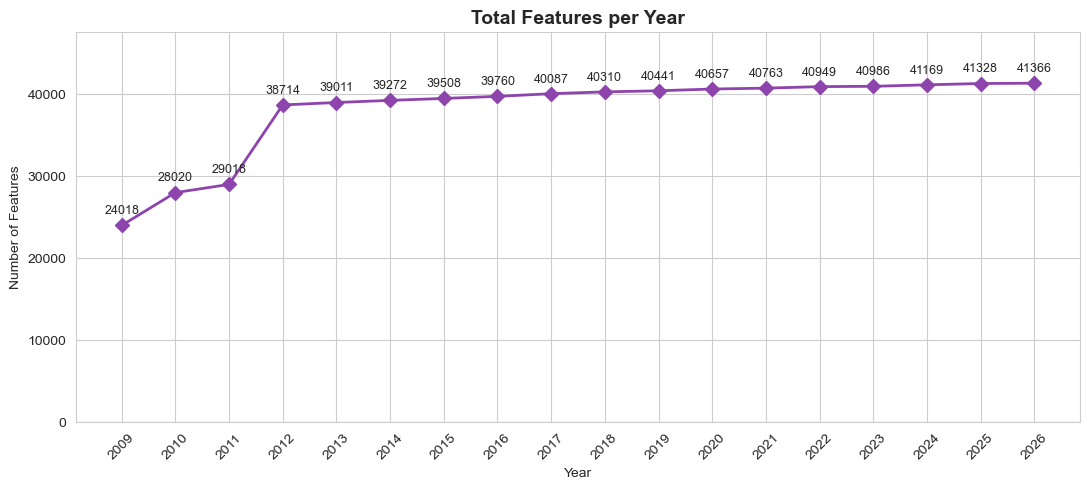

In [54]:
# 2) Plot
pdf = year_counts.to_pandas()
years = pdf["year"]
counts = pdf["n_features"]

plt.figure(figsize=(11,5))
sns.set_style("whitegrid")
plt.plot(years, counts, marker="D", color="#8e44ad", linewidth=2, markersize=7)
plt.title("Total Features per Year", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Features")
plt.xticks(years, rotation=45)
for x, y in zip(years, counts):
    plt.annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()

OUT = FIGURES_DIR / "features_per_year.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT, dpi=300, bbox_inches="tight")

plt.show()